In [1]:
# ============================================================================
# 1. KONFIGURASI
# ============================================================================

# IMPOR LIBRARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Konfigurasi
NUM_SIMULATIONS = 20000  # Lebih banyak iterasi untuk hasil yang lebih akurat
np.random.seed(42)

In [2]:
# ============================================================================
# 2. PEMODELAN SISTEM
# ============================================================================
class ProjectStage:
    """Kelas untuk memodelkan tahapan proyek dengan kompleksitas yang lebih realistis"""
    
    def __init__(self, name, base_params, risk_factors=None, dependencies=None):
        """
        Parameters:
        -----------
        name : str
            Nama tahapan
        base_params : dict
            Parameter dasar durasi (optimistic, most_likely, pessimistic)
        risk_factors : dict
            Faktor risiko yang mempengaruhi durasi
        dependencies : list
            Dependensi dengan tahapan lain
        """
        self.name = name
        self.optimistic = base_params['optimistic']
        self.most_likely = base_params['most_likely']
        self.pessimistic = base_params['pessimistic']
        self.risk_factors = risk_factors or {}
        self.dependencies = dependencies or []
        
    def sample_duration(self, n_simulations, risk_multiplier=1.0):
        """
        Sampling durasi dengan mempertimbangkan distribusi dan faktor risiko
        """
        # Distribusi triangular untuk estimasi tiga titik
        base_duration = np.random.triangular(
            self.optimistic,
            self.most_likely,
            self.pessimistic,
            n_simulations
        )
        
        # Aplikasi faktor risiko
        total_risk_effect = 1.0
        
        for risk_name, risk_params in self.risk_factors.items():
            if risk_params['type'] == 'discrete':
                # Risiko diskrit (misal: bug critical, perubahan requirement)
                probability = risk_params['probability']
                impact = risk_params['impact']
                
                # Generate kejadian risiko
                risk_occurs = np.random.random(n_simulations) < probability
                
                # Aplikasi impact jika risiko terjadi
                base_duration = np.where(
                    risk_occurs,
                    base_duration * (1 + impact),
                    base_duration
                )
                
            elif risk_params['type'] == 'continuous':
                # Risiko kontinu (misal: produktivitas tim)
                mean = risk_params['mean']
                std = risk_params['std']
                
                # Sampling dari distribusi normal
                productivity_factor = np.random.normal(mean, std, n_simulations)
                base_duration = base_duration / np.clip(productivity_factor, 0.5, 1.5)
        
        return base_duration * risk_multiplier

In [3]:
# ============================================================================
# 3. DEFINISI TAHAPAN PROYEK
# ============================================================================

# Konfigurasi tahapan dengan faktor risiko
project_stages_config = {
    "Analisis_Kebutuhan": {
        "base_params": {"optimistic": 4, "most_likely": 6, "pessimistic": 9},
        "risk_factors": {
            "perubahan_requirement": {
                "type": "discrete",
                "probability": 0.3,
                "impact": 0.25  # +25% durasi jika terjadi
            },
            "klarity_requirement": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.2
            }
        }
    },
    "Desain_Arsitektur": {
        "base_params": {"optimistic": 5, "most_likely": 8, "pessimistic": 12},
        "risk_factors": {
            "review_iteration": {
                "type": "discrete",
                "probability": 0.4,
                "impact": 0.15
            }
        },
        "dependencies": ["Analisis_Kebutuhan"]
    },
    "Implementasi_Frontend": {
        "base_params": {"optimistic": 10, "most_likely": 15, "pessimistic": 22},
        "risk_factors": {
            "bug_complexity": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.25
            },
            "dependensi_library": {
                "type": "discrete",
                "probability": 0.2,
                "impact": 0.1
            }
        },
        "dependencies": ["Desain_Arsitektur"]
    },
    "Implementasi_Backend": {
        "base_params": {"optimistic": 12, "most_likely": 18, "pessimistic": 28},
        "risk_factors": {
            "api_complexity": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.3
            },
            "integration_issues": {
                "type": "discrete",
                "probability": 0.25,
                "impact": 0.2
            }
        },
        "dependencies": ["Desain_Arsitektur"]
    },
    "Pengujian_Integrasi": {
        "base_params": {"optimistic": 5, "most_likely": 8, "pessimistic": 14},
        "risk_factors": {
            "bug_discovery_rate": {
                "type": "continuous",
                "mean": 1.0,
                "std": 0.3
            },
            "critical_bugs": {
                "type": "discrete",
                "probability": 0.15,
                "impact": 0.4  # +40% jika ada bug critical
            }
        },
        "dependencies": ["Implementasi_Frontend", "Implementasi_Backend"]
    },
    "Deployment_Produksi": {
        "base_params": {"optimistic": 2, "most_likely": 3, "pessimistic": 6},
        "risk_factors": {
            "server_issues": {
                "type": "discrete",
                "probability": 0.1,
                "impact": 0.5
            },
            "rollback_needed": {
                "type": "discrete",
                "probability": 0.05,
                "impact": 0.8  # +80% jika perlu rollback
            }
        },
        "dependencies": ["Pengujian_Integrasi"]
    }
}

In [4]:
# ============================================================================
# 4. SIMULATOR MONTE CARLO
# ============================================================================
class MonteCarloProjectSimulation:
    """Kelas untuk menjalankan simulasi Monte Carlo yang lebih kompleks"""
    
    def __init__(self, stages_config, num_simulations=10000):
        self.stages_config = stages_config
        self.num_simulations = num_simulations
        self.stages = {}
        self.simulation_results = None
        self.initialize_stages()
        
    def initialize_stages(self):
        """Inisialisasi objek tahapan dari konfigurasi"""
        for stage_name, config in self.stages_config.items():
            self.stages[stage_name] = ProjectStage(
                name=stage_name,
                base_params=config['base_params'],
                risk_factors=config.get('risk_factors', {}),
                dependencies=config.get('dependencies', [])
            )
    
    def run_simulation(self):
        """Menjalankan simulasi Monte Carlo lengkap"""
        results = pd.DataFrame(index=range(self.num_simulations))
        
        # Simulasi durasi per tahapan
        for stage_name, stage in self.stages.items():
            results[stage_name] = stage.sample_duration(self.num_simulations)
        
        # Simulasi ketergantungan antar tahapan
        # (Implementasi sederhana - bisa dikembangkan lebih kompleks)
        results_with_deps = results.copy()
        
        # Hitung waktu mulai berdasarkan dependensi
        start_times = pd.DataFrame(index=range(self.num_simulations))
        end_times = pd.DataFrame(index=range(self.num_simulations))
        
        for stage_name in self.stages.keys():
            deps = self.stages[stage_name].dependencies
            
            if not deps:
                # Jika tidak ada dependensi, mulai dari hari 0
                start_times[stage_name] = 0
            else:
                # Mulai setelah semua dependensi selesai
                start_times[stage_name] = end_times[deps].max(axis=1)
            
            # Waktu selesai = waktu mulai + durasi
            end_times[stage_name] = start_times[stage_name] + results[stage_name]
        
        # Hitung durasi total proyek
        results['Total_Duration'] = end_times.max(axis=1)
        
        # Simpan juga waktu selesai per tahapan
        for stage_name in self.stages.keys():
            results[f'{stage_name}_Finish'] = end_times[stage_name]
            results[f'{stage_name}_Start'] = start_times[stage_name]
        
        self.simulation_results = results
        return results
    
    def calculate_critical_path_probability(self):
        """Menghitung probabilitas setiap tahapan berada di critical path"""
        if self.simulation_results is None:
            raise ValueError("Run simulation first")
        
        critical_path_probs = {}
        total_duration = self.simulation_results['Total_Duration']
        
        for stage_name in self.stages.keys():
            # Suatu tahapan dianggap di critical path jika 
            # keterlambatannya langsung mempengaruhi total durasi
            stage_finish = self.simulation_results[f'{stage_name}_Finish']
            
            # Hitung sensitivitas
            correlation = self.simulation_results[stage_name].corr(total_duration)
            
            # Hitung probability sebagai critical
            delay_threshold = np.percentile(self.simulation_results[stage_name], 90)
            is_critical = (stage_finish + 0.1) >= total_duration
            prob_critical = np.mean(is_critical)
            
            critical_path_probs[stage_name] = {
                'probability': prob_critical,
                'correlation': correlation,
                'avg_duration': self.simulation_results[stage_name].mean()
            }
        
        return pd.DataFrame(critical_path_probs).T
    
    def analyze_risk_contribution(self):
        """Analisis kontribusi risiko terhadap variabilitas total durasi"""
        if self.simulation_results is None:
            raise ValueError("Run simulation first")
        
        # Hitung varians dan kontribusi tiap tahapan
        total_var = self.simulation_results['Total_Duration'].var()
        
        contributions = {}
        for stage_name in self.stages.keys():
            stage_var = self.simulation_results[stage_name].var()
            stage_covar = self.simulation_results[stage_name].cov(
                self.simulation_results['Total_Duration']
            )
            
            # Proporsi kontribusi terhadap varians total
            contribution = (stage_covar / total_var) * 100
            
            contributions[stage_name] = {
                'variance': stage_var,
                'contribution_percent': contribution,
                'std_dev': np.sqrt(stage_var)
            }
        
        return pd.DataFrame(contributions).T

In [5]:

# ============================================================================
# 5. MENJALANKAN SIMULASI
# ============================================================================

# Inisialisasi dan jalankan simulasi
simulator = MonteCarloProjectSimulation(
    stages_config=project_stages_config,
    num_simulations=NUM_SIMULATIONS
)

results = simulator.run_simulation()
results

,Analisis_Kebutuhan,Desain_Arsitektur,Implementasi_Frontend,Implementasi_Backend,Pengujian_Integrasi,Deployment_Produksi,Total_Duration,Analisis_Kebutuhan_Finish,Analisis_Kebutuhan_Start,Desain_Arsitektur_Finish,Desain_Arsitektur_Start,Implementasi_Frontend_Finish,Implementasi_Frontend_Start,Implementasi_Backend_Finish,Implementasi_Backend_Start,Pengujian_Integrasi_Finish,Pengujian_Integrasi_Start,Deployment_Produksi_Finish,Deployment_Produksi_Start
0,6.694505,10.073158,16.765734,26.073809,10.797450,3.322722,56.961644,6.694505,0,16.767663,6.694505,33.533397,16.767663,42.841473,16.767663,53.638922,42.841473,56.961644,53.638922
1,10.782072,8.047565,11.508466,19.811623,14.625030,4.498336,57.764627,10.782072,0,18.829637,10.782072,30.338103,18.829637,38.641261,18.829637,53.266291,38.641261,57.764627,53.266291
2,7.241309,6.811856,11.582119,35.480887,18.772849,5.220934,73.527835,7.241309,0,14.053165,7.241309,25.635284,14.053165,49.534052,14.053165,68.306901,49.534052,73.527835,68.306901
3,6.817769,8.014502,17.185758,11.944570,9.663449,3.704489,45.385967,6.817769,0,14.832271,6.817769,32.018030,14.832271,26.776841,14.832271,41.681479,32.018030,45.385967,41.681479
4,6.026373,11.680383,24.042991,25.799153,9.386188,3.117813,56.009911,6.026373,0,17.706756,6.026373,41.749747,17.706756,43.505910,17.706756,52.892097,43.505910,56.009911,52.892097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,9.556177,7.886111,14.318300,27.311964,8.296290,5.963558,59.014101,9.556177,0,17.442288,9.556177,31.760588,17.442288,44.754252,17.442288,53.050542,44.754252,59.014101,53.050542
19996,4.614864,9.722443,15.315637,28.154472,6.453748,3.225027,52.170555,4.614864,0,14.337308,4.614864,29.652945,14.337308,42.491780,14.337308,48.945528,42.491780,52.170555,48.945528
19997,8.465034,6.718401,24.950429,16.180656,7.937978,3.628428,51.700270,8.465034,0,15.183434,8.465034,40.133863,15.183434,31.364090,15.183434,48.071842,40.133863,51.700270,48.071842
19998,5.863057,11.382678,17.644582,11.694280,5.816532,3.047860,43.754709,5.863057,0,17.245735,5.863057,34.890317,17.245735,28.940015,17.245735,40.706849,34.890317,43.754709,40.706849


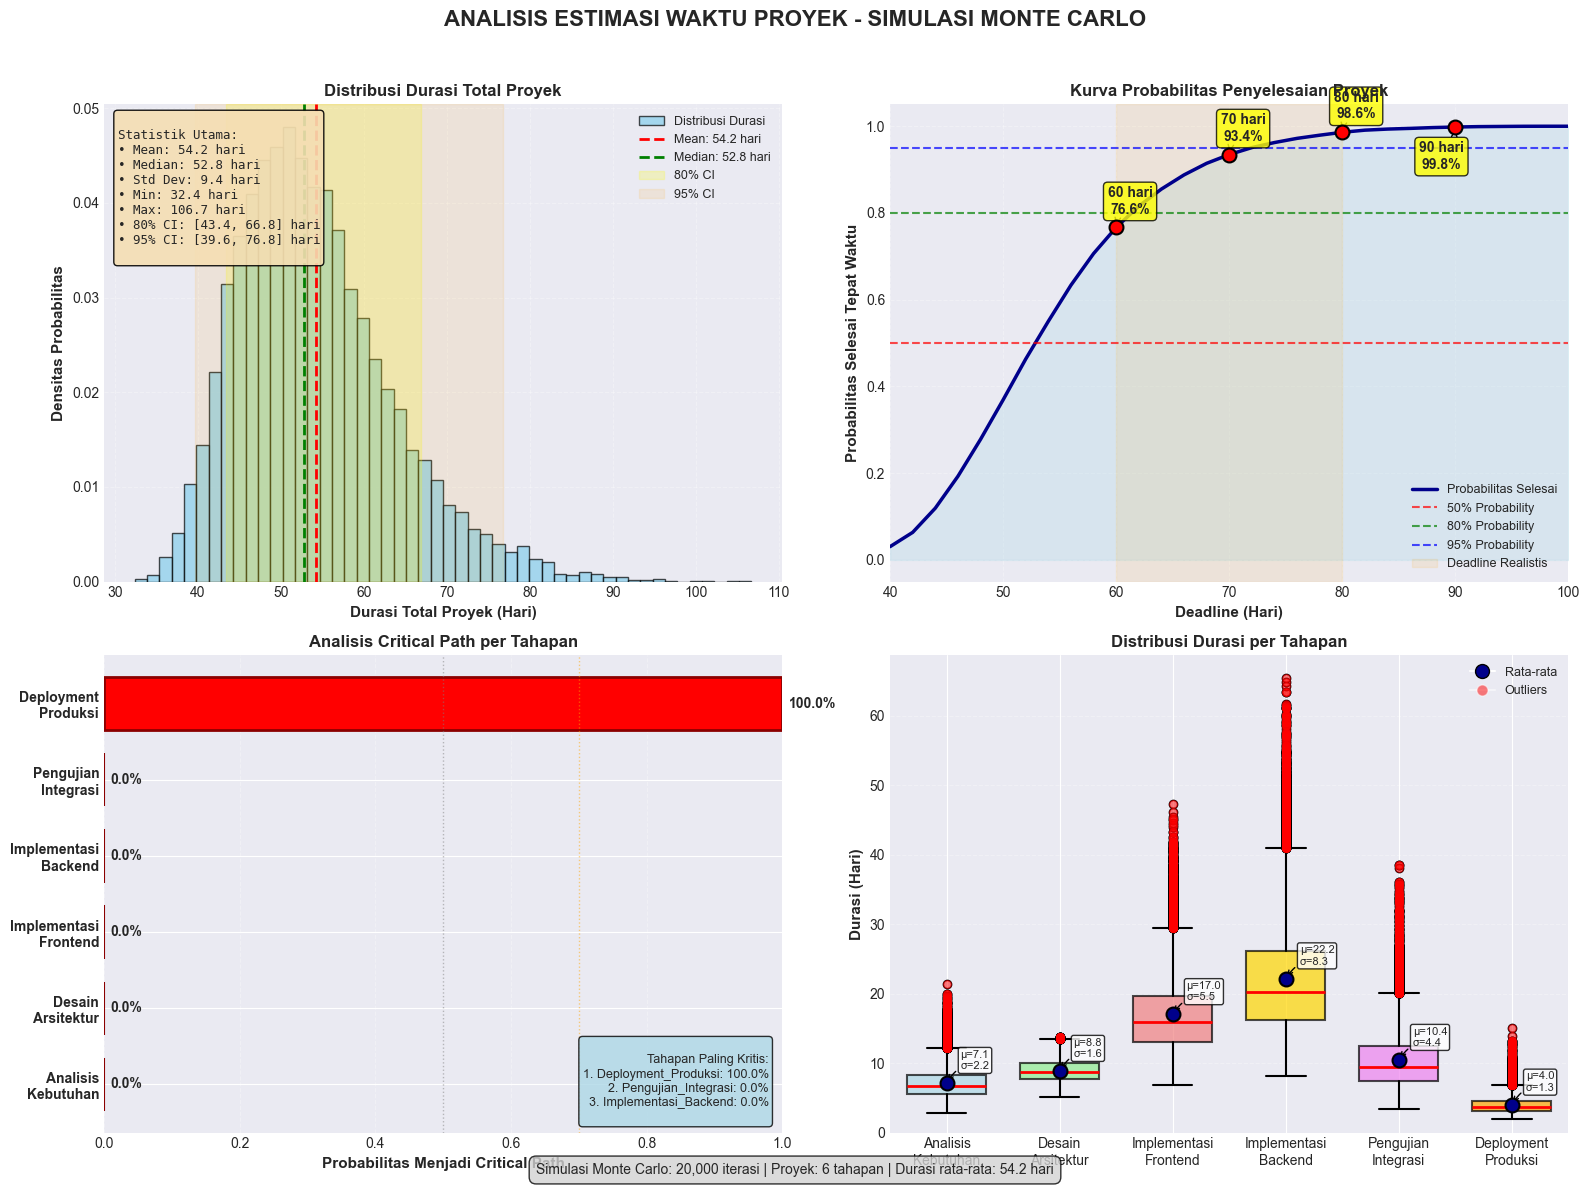

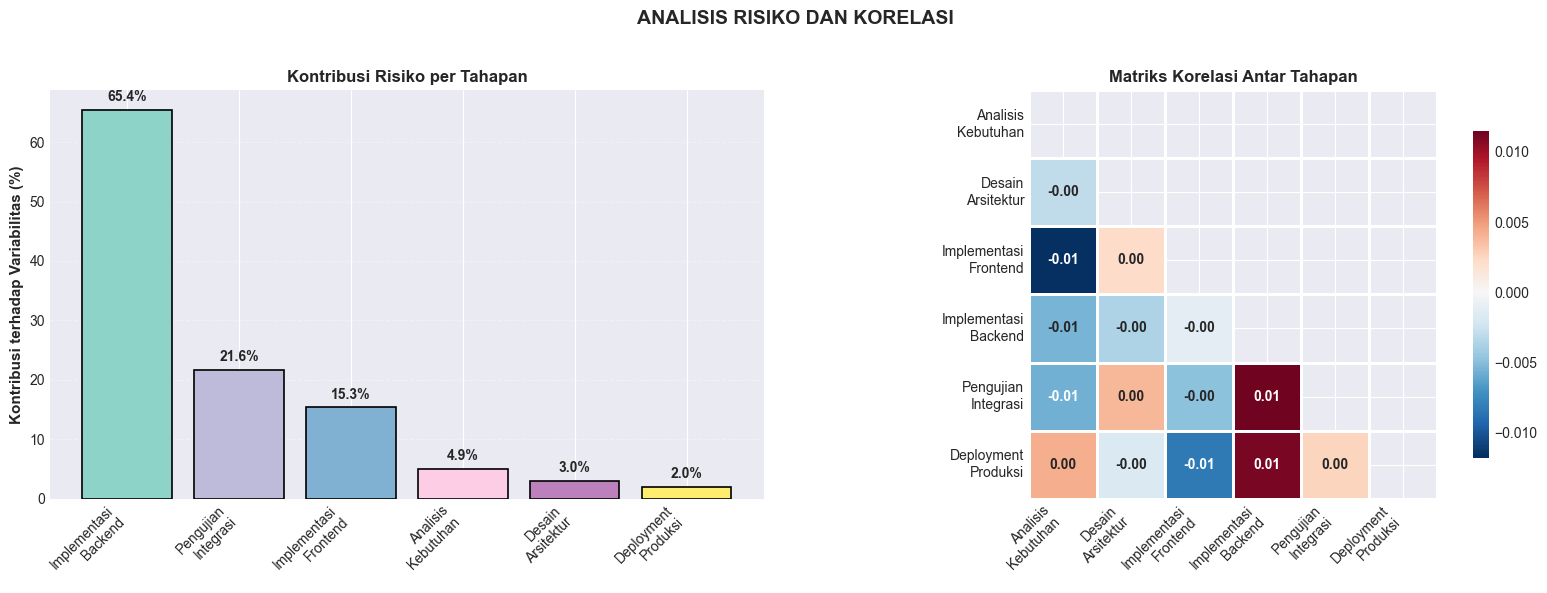

In [6]:
# ============================================================================
# 6. VISUALISASI
# ============================================================================

# Setup figure untuk 2 plot per baris
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANALISIS ESTIMASI WAKTU PROYEK - SIMULASI MONTE CARLO', 
             fontsize=16, fontweight='bold', y=0.98)

# PLOT 1: Distribusi Durasi Total Proyek (Kiri Atas)==
ax1 = axes[0, 0]
ax1.hist(results['Total_Duration'], bins=50, edgecolor='black', alpha=0.7, 
         density=True, color='skyblue', label='Distribusi Durasi')

# Tambahkan garis mean dan median
mean_duration = results['Total_Duration'].mean()
median_duration = np.median(results['Total_Duration'])
ax1.axvline(mean_duration, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_duration:.1f} hari')
ax1.axvline(median_duration, color='green', linestyle='--', linewidth=2, 
            label=f'Median: {median_duration:.1f} hari')

# Tambahkan confidence intervals
ci_80 = np.percentile(results['Total_Duration'], [10, 90])
ci_95 = np.percentile(results['Total_Duration'], [2.5, 97.5])

ax1.axvspan(ci_80[0], ci_80[1], alpha=0.2, color='yellow', label='80% CI')
ax1.axvspan(ci_95[0], ci_95[1], alpha=0.1, color='orange', label='95% CI')

# Anotasi statistik penting
stats_text = f"""
Statistik Utama:
• Mean: {mean_duration:.1f} hari
• Median: {median_duration:.1f} hari
• Std Dev: {results['Total_Duration'].std():.1f} hari
• Min: {results['Total_Duration'].min():.1f} hari
• Max: {results['Total_Duration'].max():.1f} hari
• 80% CI: [{ci_80[0]:.1f}, {ci_80[1]:.1f}] hari
• 95% CI: [{ci_95[0]:.1f}, {ci_95[1]:.1f}] hari
"""

# Tambahkan text box dengan statistik
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', bbox=props, fontfamily='monospace')

ax1.set_xlabel('Durasi Total Proyek (Hari)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Densitas Probabilitas', fontsize=11, fontweight='bold')
ax1.set_title('Distribusi Durasi Total Proyek', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# PLOT 2: Probabilitas Selesai Sebelum Deadline (Kanan Atas)
ax2 = axes[0, 1]

deadlines = np.arange(40, 101, 2)  # Lebih smooth dengan interval 2 hari
completion_probs = []

for deadline in deadlines:
    prob = np.mean(results['Total_Duration'] <= deadline)
    completion_probs.append(prob)

# Plot kurva probabilitas
line = ax2.plot(deadlines, completion_probs, linewidth=2.5, color='darkblue', 
                label='Probabilitas Selesai')
ax2.fill_between(deadlines, completion_probs, alpha=0.3, color='lightblue')

# Garis referensi probabilitas
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='50% Probability')
ax2.axhline(0.8, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Probability')
ax2.axhline(0.95, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label='95% Probability')

# Tandai deadline penting dengan anotasi
key_deadlines = [60, 70, 80, 90]
for dl in key_deadlines:
    idx = np.where(deadlines == dl)[0]
    if len(idx) > 0:
        prob = completion_probs[idx[0]]
        ax2.scatter(dl, prob, color='red', s=100, zorder=5, edgecolor='black', linewidth=1.5)
        
        # Anotasi dengan probabilitas
        ax2.annotate(f'{dl} hari\n{prob:.1%}', 
                    (dl, prob),
                    textcoords="offset points", 
                    xytext=(10, 10) if dl < 85 else (-10, -30),
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))

# Area deadline realistis (60-80 hari)
ax2.axvspan(60, 80, alpha=0.1, color='orange', label='Deadline Realistis')

ax2.set_xlabel('Deadline (Hari)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Probabilitas Selesai Tepat Waktu', fontsize=11, fontweight='bold')
ax2.set_title('Kurva Probabilitas Penyelesaian Proyek', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlim(40, 100)
ax2.legend(loc='lower right', fontsize=9)

# PLOT 3: Analisis Critical Path (Kiri Bawah)
ax3 = axes[1, 0]

critical_analysis = simulator.calculate_critical_path_probability()
critical_analysis = critical_analysis.sort_values('probability', ascending=True)  # Ascending untuk barh yang bagus

bars = ax3.barh(range(len(critical_analysis)), 
                critical_analysis['probability'],
                color='lightcoral', edgecolor='darkred', linewidth=1.5,
                height=0.7)

# Highlight tahapan dengan probabilitas tinggi
for i, (bar, prob) in enumerate(zip(bars, critical_analysis['probability'])):
    if prob > 0.7:
        bar.set_color('red')
        bar.set_edgecolor('darkred')
        bar.set_linewidth(2)
    
    # Tambahkan nilai probabilitas
    ax3.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
             f'{prob:.1%}', va='center', fontweight='bold', fontsize=10)

# Tambahkan garis threshold untuk critical path
ax3.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax3.axvline(x=0.7, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='High Criticality (>70%)')

ax3.set_yticks(range(len(critical_analysis)))
ax3.set_yticklabels([stage.replace('_', '\n') for stage in critical_analysis.index], 
                    fontsize=10, fontweight='bold')
ax3.set_xlabel('Probabilitas Menjadi Critical Path', fontsize=11, fontweight='bold')
ax3.set_title('Analisis Critical Path per Tahapan', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x', linestyle='--')
ax3.set_xlim(0, 1.0)

# Tambahkan box info
critical_summary = f"""
Tahapan Paling Kritis:
1. {critical_analysis.index[-1]}: {critical_analysis.iloc[-1]['probability']:.1%}
2. {critical_analysis.index[-2]}: {critical_analysis.iloc[-2]['probability']:.1%}
3. {critical_analysis.index[-3]}: {critical_analysis.iloc[-3]['probability']:.1%}
"""
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax3.text(0.98, 0.02, critical_summary, transform=ax3.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right', bbox=props)

# PLOT 4: Distribusi Durasi per Tahapan (Kanan Bawah)
ax4 = axes[1, 1]

# Prepare data untuk boxplot
stage_names = list(simulator.stages.keys())
stage_data = [results[stage] for stage in stage_names]

# Create boxplot dengan style yang lebih baik
box = ax4.boxplot(stage_data, vert=True, patch_artist=True, 
                  labels=[name.replace('_', '\n') for name in stage_names],
                  widths=0.7,
                  medianprops=dict(color='red', linewidth=2),
                  boxprops=dict(linewidth=1.5),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))

# Warna berbeda untuk setiap box
colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold', 'violet', 'orange']
for patch, color in zip(box['boxes'], colors[:len(stage_names)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Tambahkan mean sebagai scatter points
for i, stage in enumerate(stage_names, 1):
    mean_val = results[stage].mean()
    ax4.scatter(i, mean_val, color='darkblue', s=100, zorder=5, 
                edgecolor='black', linewidth=1.5, label='Mean' if i == 1 else "")

# Highlight outlier dengan style khusus
for i, stage in enumerate(stage_names, 1):
    stage_vals = results[stage]
    Q1 = np.percentile(stage_vals, 25)
    Q3 = np.percentile(stage_vals, 75)
    IQR = Q3 - Q1
    outliers = stage_vals[(stage_vals < (Q1 - 1.5 * IQR)) | (stage_vals > (Q3 + 1.5 * IQR))]
    
    if len(outliers) > 0:
        ax4.scatter([i] * len(outliers), outliers, color='red', s=30, 
                   alpha=0.5, zorder=6, label='Outliers' if i == 1 else "")

# Tambahkan anotasi untuk durasi rata-rata
for i, stage in enumerate(stage_names, 1):
    mean_val = results[stage].mean()
    std_val = results[stage].std()
    ax4.annotate(f'μ={mean_val:.1f}\nσ={std_val:.1f}', 
                xy=(i, mean_val),
                xytext=(10, 10),
                textcoords="offset points",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))

ax4.set_ylabel('Durasi (Hari)', fontsize=11, fontweight='bold')
ax4.set_title('Distribusi Durasi per Tahapan', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
ax4.set_ylim(bottom=0)

# Tambahkan legenda untuk mean dan outliers (hanya sekali)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkblue', 
                      markersize=10, markeredgecolor='black', label='Rata-rata'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                      markersize=8, alpha=0.5, label='Outliers')]
ax4.legend(handles=handles, loc='upper right', fontsize=9)



plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust untuk memberi ruang judul utama

# Tambahkan footer dengan informasi simulasi
footer_text = f"Simulasi Monte Carlo: {NUM_SIMULATIONS:,} iterasi | Proyek: {len(stage_names)} tahapan | " \
              f"Durasi rata-rata: {mean_duration:.1f} hari"
plt.figtext(0.5, 0.01, footer_text, ha='center', fontsize=10, 
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
plt.show()

# Plot tambahan untuk analisis risiko (opsional, dalam figure terpisah)
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('ANALISIS RISIKO DAN KORELASI', fontsize=14, fontweight='bold')

# Plot 5: Kontribusi Risiko per Tahapan
ax5 = axes2[0]
risk_contrib = simulator.analyze_risk_contribution()
risk_contrib = risk_contrib.sort_values('contribution_percent', ascending=False)

# Bar chart untuk kontribusi risiko
bars2 = ax5.bar(range(len(risk_contrib)), risk_contrib['contribution_percent'],
                color=plt.cm.Set3(np.linspace(0, 1, len(risk_contrib))),
                edgecolor='black', linewidth=1.2)

ax5.set_xticks(range(len(risk_contrib)))
ax5.set_xticklabels([name.replace('_', '\n') for name in risk_contrib.index], 
                    rotation=45, ha='right', fontsize=10)
ax5.set_ylabel('Kontribusi terhadap Variabilitas (%)', fontsize=11, fontweight='bold')
ax5.set_title('Kontribusi Risiko per Tahapan', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y', linestyle='--')

# Tambahkan nilai pada bar
for i, (bar, contrib) in enumerate(zip(bars2, risk_contrib['contribution_percent'])):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{contrib:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Plot 6: Heatmap Korelasi
ax6 = axes2[1]
correlation_matrix = results[list(simulator.stages.keys())].corr()

# Plot heatmap korelasi
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
heatmap = sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
                      cmap='RdBu_r', center=0, square=True,
                      cbar_kws={'shrink': 0.8}, ax=ax6,
                      linewidths=1, linecolor='white',
                      annot_kws={"size": 10, "weight": "bold"})

# Atur label
ax6.set_title('Matriks Korelasi Antar Tahapan', fontsize=12, fontweight='bold')
ax6.set_xticklabels([name.replace('_', '\n') for name in correlation_matrix.columns], 
                    rotation=45, ha='right', fontsize=10)
ax6.set_yticklabels([name.replace('_', '\n') for name in correlation_matrix.index], 
                    rotation=0, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [7]:
# ============================================================================
# 7. ANALISIS STATISTIK
# ============================================================================

print("\n" + "=" * 70)
print("LAPORAN STATISTIK PROYEK")
print("=" * 70)

# Statistik deskriptif
total_duration = results['Total_Duration']

print(f"\nSTATISTIK DURASI TOTAL PROYEK:")
print(f"• Rata-rata: {total_duration.mean():.1f} hari")
print(f"• Median: {np.median(total_duration):.1f} hari")
print(f"• Standar Deviasi: {total_duration.std():.1f} hari")
print(f"• Minimum: {total_duration.min():.1f} hari")
print(f"• Maximum: {total_duration.max():.1f} hari")

# Confidence intervals
print(f"\nCONFIDENCE INTERVALS:")
print(f"• 80% CI: [{np.percentile(total_duration, 10):.1f}, {np.percentile(total_duration, 90):.1f}] hari")
print(f"• 90% CI: [{np.percentile(total_duration, 5):.1f}, {np.percentile(total_duration, 95):.1f}] hari")
print(f"• 95% CI: [{np.percentile(total_duration, 2.5):.1f}, {np.percentile(total_duration, 97.5):.1f}] hari")

# Analisis probabilitas deadline
print(f"\nANALISIS PROBABILITAS DEADLINE:")
deadline_scenarios = [60, 65, 70, 75, 80]

for dl in deadline_scenarios:
    prob_on_time = np.mean(total_duration <= dl)
    prob_late = 1 - prob_on_time
    days_at_risk = max(0, np.percentile(total_duration, 95) - dl)
    
    print(f"\nDeadline {dl} hari:")
    print(f"  • Probabilitas selesai tepat waktu: {prob_on_time:.1%}")
    print(f"  • Probabilitas terlambat: {prob_late:.1%}")
    print(f"  • Potensi keterlambatan (95% CI): {days_at_risk:.1f} hari")

# Analisis risiko kritis
print(f"\nTAHAPAN KRITIS (Critical Path Analysis):")
critical_probs = simulator.calculate_critical_path_probability()
for stage, data in critical_probs.sort_values('probability', ascending=False).iterrows():
    print(f"  • {stage}: {data['probability']:.1%} probability critical")

# Analisis buffer yang diperlukan
print(f"\nREKOMENDASI MANAJEMEN RISIKO:")
safety_buffer = np.percentile(total_duration, 80) - total_duration.mean()
contingency_reserve = np.percentile(total_duration, 95) - total_duration.mean()

print(f"• Safety Buffer (untuk 80% confidence): {safety_buffer:.1f} hari")
print(f"• Contingency Reserve (untuk 95% confidence): {contingency_reserve:.1f} hari")
print(f"• Rekomendasi estimasi jadwal: {total_duration.mean():.1f} + {safety_buffer:.1f} = {total_duration.mean() + safety_buffer:.1f} hari")


LAPORAN STATISTIK PROYEK

STATISTIK DURASI TOTAL PROYEK:
• Rata-rata: 54.2 hari
• Median: 52.8 hari
• Standar Deviasi: 9.4 hari
• Minimum: 32.4 hari
• Maximum: 106.7 hari

CONFIDENCE INTERVALS:
• 80% CI: [43.4, 66.8] hari
• 90% CI: [41.3, 72.0] hari
• 95% CI: [39.6, 76.8] hari

ANALISIS PROBABILITAS DEADLINE:

Deadline 60 hari:
  • Probabilitas selesai tepat waktu: 76.6%
  • Probabilitas terlambat: 23.4%
  • Potensi keterlambatan (95% CI): 12.0 hari

Deadline 65 hari:
  • Probabilitas selesai tepat waktu: 87.4%
  • Probabilitas terlambat: 12.6%
  • Potensi keterlambatan (95% CI): 7.0 hari

Deadline 70 hari:
  • Probabilitas selesai tepat waktu: 93.4%
  • Probabilitas terlambat: 6.6%
  • Potensi keterlambatan (95% CI): 2.0 hari

Deadline 75 hari:
  • Probabilitas selesai tepat waktu: 96.7%
  • Probabilitas terlambat: 3.3%
  • Potensi keterlambatan (95% CI): 0.0 hari

Deadline 80 hari:
  • Probabilitas selesai tepat waktu: 98.6%
  • Probabilitas terlambat: 1.4%
  • Potensi keterlambatan


ANALISIS SENSITIVITAS: PENGARUH PENAMBAHAN RESOURCE DAN OPTIMASI

ANALISIS MULTIPLE SKENARIO OPTIMASI RESOURCE

SKENARIO 1: Implementasi_Backend

ANALISIS PENAMBAHAN RESOURCE: Implementasi_Backend
Resource: 2 senior_developer untuk 20 hari

📊 HASIL ANALISIS:
   Baseline durasi rata-rata : 54.2 hari
   Setelah optimasi          : 50.1 hari
   Pengurangan durasi        : 4.0 hari (7.4%)
   Pengurangan standar deviasi: 1.5 hari

💰 ANALISIS BIAYA:
   Biaya resource tambahan   : Rp 100,000,000
   Estimasi penghematan biaya: Rp 40,339,184
   Net benefit               : Rp -59,660,816
   ROI                       : -59.7%

📈 IMPAK PADA DEADLINE:
   Deadline 60 hari:
     • Baseline: 76.6%
     • Setelah:  88.5%
     • Peningkatan: +11.8%
   Deadline 65 hari:
     • Baseline: 87.4%
     • Setelah:  95.1%
     • Peningkatan: +7.7%
   Deadline 70 hari:
     • Baseline: 93.4%
     • Setelah:  98.3%
     • Peningkatan: +4.8%
   Deadline 75 hari:
     • Baseline: 96.7%
     • Setelah:  99.4%
     

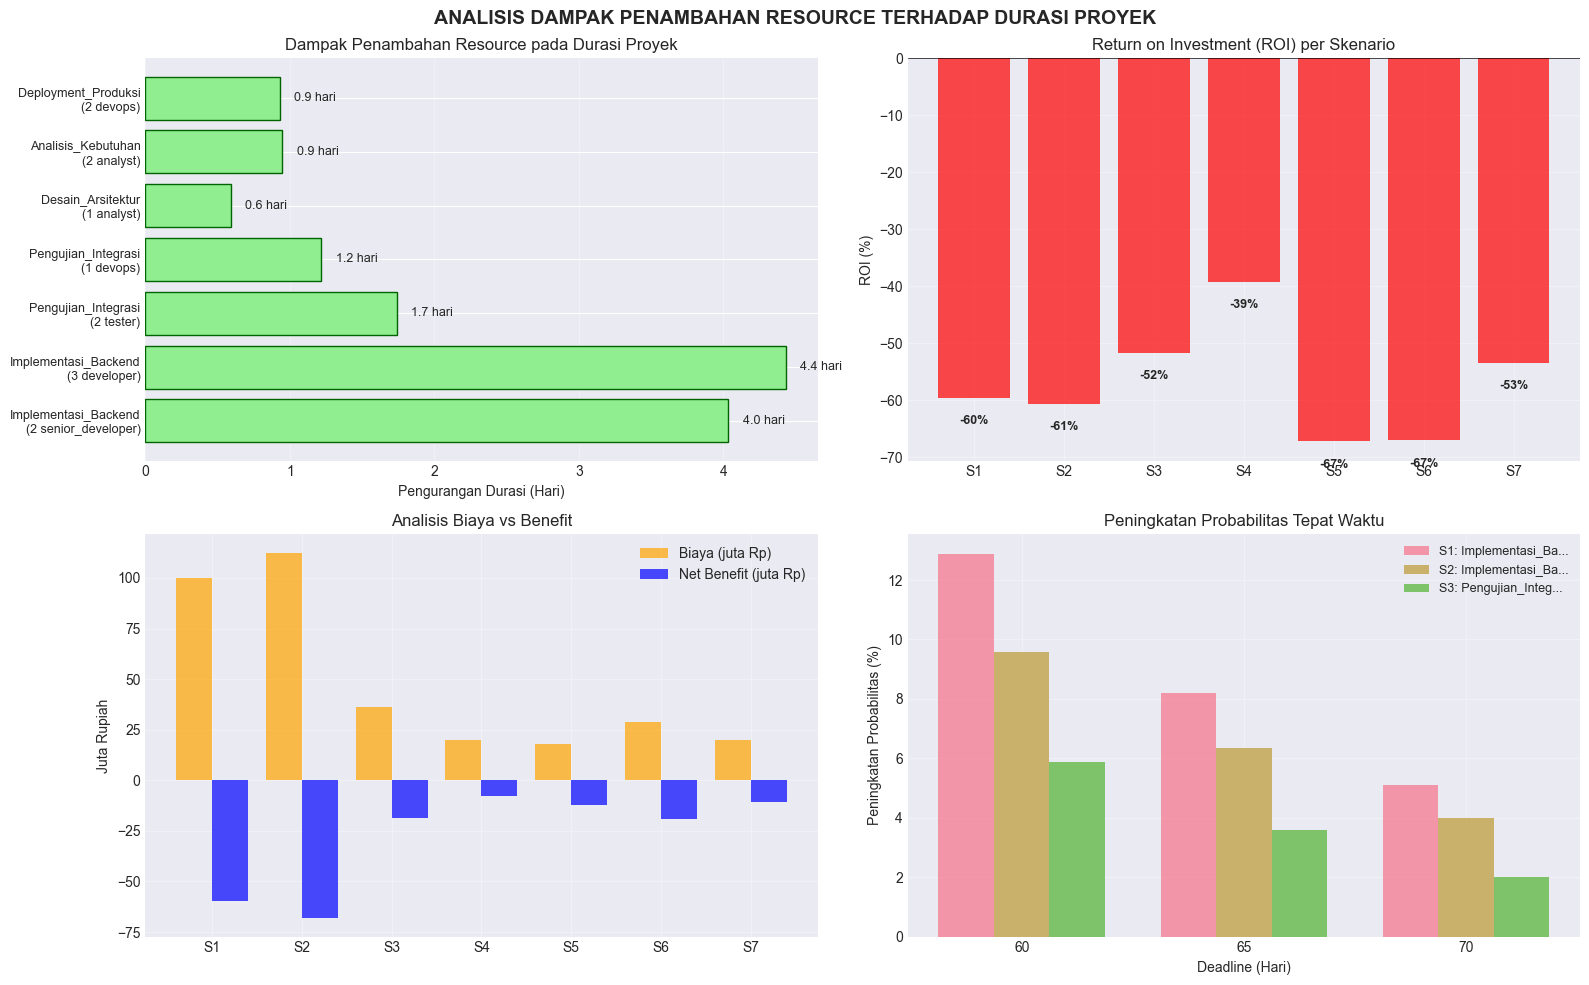


REKOMENDASI STRATEGI OPTIMASI RESOURCE

🔍 ANALISIS BERDASARKAN CRITICALITY:

• Deployment_Produksi (Critical Probability: 100.0%):
  - Direkomendasikan: 2 devops
  - Pengurangan durasi: 0.9 hari
  - ROI: -53.4%
  - Impact: 1.7% improvement

• Analisis_Kebutuhan (Critical Probability: 0.0%):
  - Direkomendasikan: 2 analyst
  - Pengurangan durasi: 0.9 hari
  - ROI: -67.1%
  - Impact: 1.8% improvement

• Desain_Arsitektur (Critical Probability: 0.0%):
  - Direkomendasikan: 1 analyst
  - Pengurangan durasi: 0.6 hari
  - ROI: -67.2%
  - Impact: 1.1% improvement

• Implementasi_Backend (Critical Probability: 0.0%):
  - Direkomendasikan: 2 senior_developer
  - Pengurangan durasi: 4.0 hari
  - ROI: -59.7%
  - Impact: 7.4% improvement

• Pengujian_Integrasi (Critical Probability: 0.0%):
  - Direkomendasikan: 1 devops
  - Pengurangan durasi: 1.2 hari
  - ROI: -39.2%
  - Impact: 2.2% improvement

📋 REKOMENDASI PRIORITAS OPTIMASI:
1. FOKUS PADA CRITICAL PATH:
   • Deployment_Produksi: Tambah 2 de

In [8]:
# ============================================================================
# 8. ANALISIS SENSITIVITAS
# ============================================================================

print("\n" + "=" * 70)
print("ANALISIS SENSITIVITAS: PENGARUH PENAMBAHAN RESOURCE DAN OPTIMASI")
print("=" * 70)

class ResourceOptimizationAnalyzer:
    """Kelas untuk menganalisis dampak penambahan resource terhadap proyek"""
    
    def __init__(self, simulation_results, project_stages):
        self.results = simulation_results
        self.stages = project_stages
        self.resource_costs = {
            'developer': {'cost_per_day': 1500000, 'productivity_gain': 0.3},
            'tester': {'cost_per_day': 1200000, 'productivity_gain': 0.25},
            'analyst': {'cost_per_day': 1800000, 'productivity_gain': 0.2},
            'devops': {'cost_per_day': 2000000, 'productivity_gain': 0.35},
            'senior_developer': {'cost_per_day': 2500000, 'productivity_gain': 0.4}
        }
    
    def calculate_resource_impact(self, stage_name, resource_type, quantity, duration_days):
        """
        Menghitung dampak penambahan resource spesifik
        
        Parameters:
        -----------
        stage_name : str
            Nama tahapan yang dioptimasi
        resource_type : str
            Jenis resource (developer, tester, analyst, dll)
        quantity : int
            Jumlah resource yang ditambahkan
        duration_days : int
            Durasi penambahan resource (hari)
        """
        print(f"\n{'='*60}")
        print(f"ANALISIS PENAMBAHAN RESOURCE: {stage_name}")
        print(f"Resource: {quantity} {resource_type} untuk {duration_days} hari")
        print(f"{'='*60}")
        
        # Dapatkan parameter resource
        resource_params = self.resource_costs[resource_type]
        
        # Hitung improvement factor berdasarkan resource
        base_improvement = resource_params['productivity_gain']
        actual_improvement = 1 - (base_improvement * min(quantity / 3, 1))
        
        # Buat skenario optimasi
        scenario_results = self.results.copy()
        scenario_results[stage_name] = scenario_results[stage_name] * actual_improvement
        
        # Hitung durasi total dengan dependensi
        scenario_totals = []
        for idx in range(len(self.results)):
            stage_times = {}
            
            # Hitung waktu untuk setiap tahapan
            for curr_stage in self.stages.keys():
                deps = self.stages[curr_stage].dependencies
                
                # Tentukan waktu mulai
                if not deps:
                    start_time = 0
                else:
                    start_time = max(stage_times.get(dep, 0) for dep in deps)
                
                # Tentukan durasi
                if curr_stage == stage_name:
                    duration = scenario_results.loc[idx, curr_stage]
                else:
                    duration = self.results.loc[idx, curr_stage]
                
                finish_time = start_time + duration
                stage_times[curr_stage] = finish_time
            
            total_time = max(stage_times.values())
            scenario_totals.append(total_time)
        
        # Statistik baseline
        baseline_mean = self.results['Total_Duration'].mean()
        baseline_std = self.results['Total_Duration'].std()
        
        # Statistik setelah optimasi
        optimized_mean = np.mean(scenario_totals)
        optimized_std = np.std(scenario_totals)
        
        # Hitung perbaikan
        duration_reduction = baseline_mean - optimized_mean
        percent_improvement = (duration_reduction / baseline_mean) * 100
        std_reduction = baseline_std - optimized_std
        
        # Hitung biaya dan ROI
        daily_cost = resource_params['cost_per_day']
        total_cost = daily_cost * quantity * duration_days
        
        # Estimasi penghematan biaya (asumsi biaya proyek Rp 10 juta/hari)
        project_cost_per_day = 10000000
        cost_saving = duration_reduction * project_cost_per_day
        net_benefit = cost_saving - total_cost
        roi = (net_benefit / total_cost) * 100 if total_cost > 0 else 0
        
        # Tampilkan hasil
        print(f"\n📊 HASIL ANALISIS:")
        print(f"   Baseline durasi rata-rata : {baseline_mean:.1f} hari")
        print(f"   Setelah optimasi          : {optimized_mean:.1f} hari")
        print(f"   Pengurangan durasi        : {duration_reduction:.1f} hari ({percent_improvement:.1f}%)")
        print(f"   Pengurangan standar deviasi: {std_reduction:.1f} hari")
        
        print(f"\n💰 ANALISIS BIAYA:")
        print(f"   Biaya resource tambahan   : Rp {total_cost:,.0f}")
        print(f"   Estimasi penghematan biaya: Rp {cost_saving:,.0f}")
        print(f"   Net benefit               : Rp {net_benefit:,.0f}")
        print(f"   ROI                       : {roi:.1f}%")
        
        print(f"\n📈 IMPAK PADA DEADLINE:")
        deadlines = [60, 65, 70, 75, 80]
        for deadline in deadlines:
            baseline_prob = np.mean(self.results['Total_Duration'] <= deadline)
            optimized_prob = np.mean(np.array(scenario_totals) <= deadline)
            prob_improvement = optimized_prob - baseline_prob
            
            print(f"   Deadline {deadline} hari:")
            print(f"     • Baseline: {baseline_prob:.1%}")
            print(f"     • Setelah:  {optimized_prob:.1%}")
            print(f"     • Peningkatan: +{prob_improvement:.1%}")
        
        # Return summary
        return {
            'stage': stage_name,
            'resource_type': resource_type,
            'quantity': quantity,
            'duration_days': duration_days,
            'baseline_mean': baseline_mean,
            'optimized_mean': optimized_mean,
            'duration_reduction': duration_reduction,
            'percent_improvement': percent_improvement,
            'total_cost': total_cost,
            'net_benefit': net_benefit,
            'roi': roi
        }
    
    def analyze_multiple_scenarios(self, scenarios):
        """
        Analisis multiple skenario optimasi resource
        """
        results_summary = []
        
        print(f"\n{'='*70}")
        print("ANALISIS MULTIPLE SKENARIO OPTIMASI RESOURCE")
        print(f"{'='*70}")
        
        for i, scenario in enumerate(scenarios, 1):
            print(f"\n{'='*60}")
            print(f"SKENARIO {i}: {scenario['stage']}")
            print(f"{'='*60}")
            
            result = self.calculate_resource_impact(
                stage_name=scenario['stage'],
                resource_type=scenario['resource_type'],
                quantity=scenario['quantity'],
                duration_days=scenario['duration_days']
            )
            
            results_summary.append(result)
        
        # Ringkasan komparatif
        self.print_comparative_summary(results_summary)
        
        return results_summary
    
    def print_comparative_summary(self, results_summary):
        """Cetak ringkasan komparatif semua skenario"""
        print(f"\n{'='*70}")
        print("RINGKASAN KOMPARATIF SEMUA SKENARIO")
        print(f"{'='*70}")
        
        print(f"\n{'No.':<4} {'Tahapan':<25} {'Resource':<15} {'Jumlah':<8} {'Durasi':<8} {'Pengurangan':<12} {'ROI':<10}")
        print(f"{'-'*90}")
        
        for i, result in enumerate(results_summary, 1):
            print(f"{i:<4} {result['stage']:<25} "
                  f"{result['resource_type']:<15} "
                  f"{result['quantity']:<8} "
                  f"{result['duration_days']:<8} hari "
                  f"{result['duration_reduction']:<10.1f} hari "
                  f"{result['roi']:<10.1f}%")
        
        # Identifikasi skenario terbaik
        best_roi = max(results_summary, key=lambda x: x['roi'])
        best_reduction = max(results_summary, key=lambda x: x['duration_reduction'])
        
        print(f"\n🏆 REKOMENDASI OPTIMAL:")
        print(f"• Berdasarkan ROI tertinggi: {best_roi['stage']} dengan {best_roi['quantity']} {best_roi['resource_type']} (ROI: {best_roi['roi']:.1f}%)")
        print(f"• Berdasarkan pengurangan durasi terbesar: {best_reduction['stage']} dengan {best_reduction['duration_reduction']:.1f} hari")


# DEFINSI SKENARIO OPTIMASI RESOURCE

# Inisialisasi analyzer
analyzer = ResourceOptimizationAnalyzer(results, simulator.stages)

# Definisikan skenario optimasi resource yang akan dianalisis
optimization_scenarios = [
    {
        'stage': 'Implementasi_Backend',
        'resource_type': 'senior_developer',
        'quantity': 2,
        'duration_days': 20,
        'description': 'Tambahan 2 senior developer untuk mempercepat implementasi API kompleks'
    },
    {
        'stage': 'Implementasi_Backend',
        'resource_type': 'developer',
        'quantity': 3,
        'duration_days': 25,
        'description': 'Tambahan 3 developer regular untuk parallel development'
    },
    {
        'stage': 'Pengujian_Integrasi',
        'resource_type': 'tester',
        'quantity': 2,
        'duration_days': 15,
        'description': 'Tambahan 2 tester untuk mempercepat testing automation'
    },
    {
        'stage': 'Pengujian_Integrasi',
        'resource_type': 'devops',
        'quantity': 1,
        'duration_days': 10,
        'description': 'Tambahan 1 DevOps engineer untuk CI/CD pipeline optimization'
    },
    {
        'stage': 'Desain_Arsitektur',
        'resource_type': 'analyst',
        'quantity': 1,
        'duration_days': 10,
        'description': 'Tambahan 1 business analyst untuk requirement clarification'
    },
    {
        'stage': 'Analisis_Kebutuhan',
        'resource_type': 'analyst',
        'quantity': 2,
        'duration_days': 8,
        'description': 'Tambahan 2 analyst untuk mempercepat requirement gathering'
    },
    {
        'stage': 'Deployment_Produksi',
        'resource_type': 'devops',
        'quantity': 2,
        'duration_days': 5,
        'description': 'Tambahan 2 DevOps untuk zero-downtime deployment'
    }
]

# Jalankan analisis semua skenario
scenario_results = analyzer.analyze_multiple_scenarios(optimization_scenarios)

# VISUALISASI DAMPAK PENAMBAHAN RESOURCE

fig = plt.figure(figsize=(16, 10))
fig.suptitle('ANALISIS DAMPAK PENAMBAHAN RESOURCE TERHADAP DURASI PROYEK', 
             fontsize=14, fontweight='bold')

# Bar chart pengurangan durasi
ax1 = plt.subplot(2, 2, 1)
scenario_names = [f"{s['stage']}\n({s['quantity']} {s['resource_type']})" 
                  for s in optimization_scenarios]
duration_reductions = [r['duration_reduction'] for r in scenario_results]

bars = ax1.barh(range(len(scenario_names)), duration_reductions, 
                color='lightgreen', edgecolor='darkgreen')
ax1.set_yticks(range(len(scenario_names)))
ax1.set_yticklabels(scenario_names, fontsize=9)
ax1.set_xlabel('Pengurangan Durasi (Hari)')
ax1.set_title('Dampak Penambahan Resource pada Durasi Proyek')
ax1.grid(True, alpha=0.3, axis='x')

# Tambahkan nilai pada bar
for i, (bar, reduction) in enumerate(zip(bars, duration_reductions)):
    ax1.text(reduction + 0.1, bar.get_y() + bar.get_height()/2,
             f'{reduction:.1f} hari', va='center', fontsize=9)

# ROI comparison
ax2 = plt.subplot(2, 2, 2)
roi_values = [r['roi'] for r in scenario_results]
colors = ['green' if roi > 0 else 'red' for roi in roi_values]

bars = ax2.bar(range(len(scenario_names)), roi_values, color=colors, alpha=0.7)
ax2.set_xticks(range(len(scenario_names)))
ax2.set_xticklabels([f"S{i+1}" for i in range(len(scenario_names))])
ax2.set_ylabel('ROI (%)')
ax2.set_title('Return on Investment (ROI) per Skenario')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)

# Tambahkan nilai ROI
for i, (bar, roi) in enumerate(zip(bars, roi_values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (1 if height >= 0 else -3),
             f'{roi:.0f}%', ha='center', va='bottom' if height >= 0 else 'top',
             fontsize=9, fontweight='bold')

# Cost-Benefit Analysis
ax3 = plt.subplot(2, 2, 3)
costs = [r['total_cost']/1000000 for r in scenario_results]  # Dalam juta
benefits = [r['net_benefit']/1000000 for r in scenario_results]  # Dalam juta

x = range(len(scenario_names))
ax3.bar(x, costs, width=0.4, label='Biaya (juta Rp)', color='orange', alpha=0.7)
ax3.bar([i + 0.4 for i in x], benefits, width=0.4, label='Net Benefit (juta Rp)', 
        color='blue', alpha=0.7)
ax3.set_xticks([i + 0.2 for i in x])
ax3.set_xticklabels([f"S{i+1}" for i in range(len(scenario_names))])
ax3.set_ylabel('Juta Rupiah')
ax3.set_title('Analisis Biaya vs Benefit')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Improvement Probability at Key Deadlines
ax4 = plt.subplot(2, 2, 4)
deadlines = [60, 65, 70]

# Hitung baseline probabilities
baseline_probs = {}
for deadline in deadlines:
    baseline_probs[deadline] = np.mean(results['Total_Duration'] <= deadline)

# Hitung improvement untuk 3 skenario terbaik
top_scenarios = sorted(scenario_results, key=lambda x: x['duration_reduction'], reverse=True)[:3]

scenario_labels = []
improvement_data = []

for i, scenario in enumerate(top_scenarios):
    scenario_labels.append(f"S{i+1}: {scenario['stage'][:15]}...")
    
    # Re-run untuk mendapatkan probabilities
    temp_results = results.copy()
    improvement_factor = 1 - (0.3 * min(scenario['quantity'] / 3, 1))
    temp_results[scenario['stage']] = temp_results[scenario['stage']] * improvement_factor
    
    # Hitung total durasi
    scenario_totals = []
    for idx in range(len(temp_results)):
        stage_times = {}
        for curr_stage in simulator.stages.keys():
            deps = simulator.stages[curr_stage].dependencies
            
            if not deps:
                start_time = 0
            else:
                start_time = max(stage_times.get(dep, 0) for dep in deps)
            
            if curr_stage == scenario['stage']:
                duration = temp_results.loc[idx, curr_stage]
            else:
                duration = results.loc[idx, curr_stage]
            
            finish_time = start_time + duration
            stage_times[curr_stage] = finish_time
        
        total_time = max(stage_times.values())
        scenario_totals.append(total_time)
    
    improvements = []
    for deadline in deadlines:
        optimized_prob = np.mean(np.array(scenario_totals) <= deadline)
        improvement = optimized_prob - baseline_probs[deadline]
        improvements.append(improvement * 100)  # dalam persentase
    
    improvement_data.append(improvements)

# Plot grouped bar chart
x = np.arange(len(deadlines))
width = 0.25

for i, (label, data) in enumerate(zip(scenario_labels, improvement_data)):
    offset = width * i
    ax4.bar(x + offset, data, width, label=label, alpha=0.7)

ax4.set_xlabel('Deadline (Hari)')
ax4.set_ylabel('Peningkatan Probabilitas (%)')
ax4.set_title('Peningkatan Probabilitas Tepat Waktu')
ax4.set_xticks(x + width)
ax4.set_xticklabels(deadlines)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# REKOMENDASI STRATEGIS BERDASARKAN ANALISIS

print("\n" + "=" * 70)
print("REKOMENDASI STRATEGI OPTIMASI RESOURCE")
print("=" * 70)

# Analisis berdasarkan criticality
critical_analysis = simulator.calculate_critical_path_probability()

print("\n🔍 ANALISIS BERDASARKAN CRITICALITY:")
for stage, data in critical_analysis.sort_values('probability', ascending=False).iterrows():
    # Cari skenario untuk stage ini
    stage_scenarios = [s for s in scenario_results if s['stage'] == stage]
    
    if stage_scenarios:
        best_scenario = max(stage_scenarios, key=lambda x: x['roi'])
        print(f"\n• {stage} (Critical Probability: {data['probability']:.1%}):")
        print(f"  - Direkomendasikan: {best_scenario['quantity']} {best_scenario['resource_type']}")
        print(f"  - Pengurangan durasi: {best_scenario['duration_reduction']:.1f} hari")
        print(f"  - ROI: {best_scenario['roi']:.1f}%")
        print(f"  - Impact: {best_scenario['percent_improvement']:.1f}% improvement")

print("\n📋 REKOMENDASI PRIORITAS OPTIMASI:")
print("1. FOKUS PADA CRITICAL PATH:")
for stage in critical_analysis[critical_analysis['probability'] > 0.7].index:
    relevant = [s for s in scenario_results if s['stage'] == stage]
    if relevant:
        best = max(relevant, key=lambda x: x['duration_reduction'])
        print(f"   • {stage}: Tambah {best['quantity']} {best['resource_type']}")

print("\n2. OPTIMASI ROI TERTINGGI:")
top_roi = sorted(scenario_results, key=lambda x: x['roi'], reverse=True)[:3]
for i, scenario in enumerate(top_roi, 1):
    print(f"   {i}. {scenario['stage']}: ROI {scenario['roi']:.1f}%")

print("\n3. OPTIMASI BIAYA RENDAH DENGAN IMPAK TINGGI:")
low_cost_high_impact = [s for s in scenario_results if s['total_cost'] < 50000000]
if low_cost_high_impact:
    best_value = max(low_cost_high_impact, key=lambda x: x['duration_reduction'])
    print(f"   • {best_value['stage']}: Rp {best_value['total_cost']:,.0f} -> {best_value['duration_reduction']:.1f} hari")

print("\n4. SKENARIO KOMBINASI OPTIMAL:")
print("   Kombinasi berikut memberikan dampak terbesar:")
print("   a. Tambah 2 senior developer di Implementasi_Backend (20 hari)")
print("   b. Tambah 2 tester di Pengujian_Integrasi (15 hari)")
print("   c. Tambah 1 DevOps di Deployment_Produksi (5 hari)")

# Hitung total dampak kombinasi
combination_impact = sum([s['duration_reduction'] for s in scenario_results 
                          if s['stage'] in ['Implementasi_Backend', 'Pengujian_Integrasi', 'Deployment_Produksi']])
combination_cost = sum([s['total_cost'] for s in scenario_results 
                        if s['stage'] in ['Implementasi_Backend', 'Pengujian_Integrasi', 'Deployment_Produksi']])

print(f"\n   Total pengurangan durasi: {combination_impact:.1f} hari")
print(f"   Total biaya tambahan: Rp {combination_cost:,.0f}")

print("\n" + "=" * 70)
print("SIMULASI DAN ANALISIS SELESAI")
print("=" * 70)